In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'bcosgnn').is_dir():
            return p
    raise RuntimeError('Could not locate repo root (pyproject.toml + bcosgnn/).')

project_root = find_repo_root(current_dir)

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Repo root added: {project_root}")

Repo root added: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique


In [4]:
import random
from collections import defaultdict
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import MeanAggregation

from tqdm.auto import tqdm

from bcos.modules import BcosLinear
from bcosgnn.explain_edge_attr import explain as explain_edge_attr
import os
import shutil
from torch_geometric.data import InMemoryDataset
import tqdm

In [5]:
import torch
import os
from pathlib import Path
from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader

class ZincProcessedDataset(InMemoryDataset):
    def __init__(self, root, transform=None, pre_transform=None):
        super().__init__(root, transform, pre_transform)
        
        # Explicitly constructing the path to ensure it is correct
        data_path = Path(self.processed_dir) / "data.pt"
        
        print(f"Loading data from: {data_path.resolve()}")
        
        try:
             # weights_only=False required for PyTorch 2.6+ for PyG Data objects
            self.data, self.slices = torch.load(data_path, weights_only=False)
        except TypeError: 
            # Fallback for older PyTorch versions
            self.data, self.slices = torch.load(data_path)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        pass

    def process(self):
        pass

cwd = Path.cwd()
print(f"Current Working Directory: {cwd}")


if (cwd / "zinc_di_halo_benzene_data").exists():
    dataset_path = "zinc_di_halo_benzene_data"
elif (cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data").exists():
    dataset_path = "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
else:

    potential_path = cwd / "shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data"
    dataset_path = str(potential_path)

print(f"Using dataset path: {dataset_path}")

try:
    dataset = ZincProcessedDataset(root=dataset_path)
    print(f"Dataset loaded: {len(dataset)} graphs")
    print(f"Number of features: {dataset.num_features}")
    print(f"Number of classes: {dataset.num_classes}")

    # Create DataLoader
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    print(f"DataLoader created with {len(loader)} batches")

except Exception as e:
    print(f"Error loading dataset: {e}")


Current Working Directory: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/multi_class_Zinc
Using dataset path: zinc_di_halo_benzene_data
Loading data from: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/codes/multi_class_Zinc/zinc_di_halo_benzene_data/processed/data.pt
Dataset loaded: 9000 graphs
Number of features: 10
Number of classes: 9
DataLoader created with 282 batches


## Bcos Model Definition

In [6]:

# 4-layer BCos-GINE for `zinc_dichloro` (continuous x and edge_attr)
class BCosGINE(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        *,
        hidden_dim: int = 128,
        num_layers: int = 4,
        num_classes: int = 9,
        b: float = 2.0,
        max_out: int = 1,
        dropout: float = 0.5,
    ):
        super().__init__()
        self.lin_node = BcosLinear(node_dim, hidden_dim, b=b, max_out=max_out)
        self.lin_edge = BcosLinear(edge_dim, hidden_dim, b=b, max_out=max_out)
        self.convs = nn.ModuleList([
            GINEConv(BcosLinear(hidden_dim, hidden_dim, b=b, max_out=max_out), train_eps=False)
            for _ in range(num_layers)
        ])
        self.norms = nn.ModuleList([nn.BatchNorm1d(hidden_dim) for _ in range(num_layers)])
        self.agg = MeanAggregation()
        self.dropout = nn.Dropout(dropout)
        self.head = BcosLinear(hidden_dim, num_classes, b=b, max_out=max_out)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor, batch: torch.Tensor) -> torch.Tensor:
        x = self.lin_node(x)
        edge_attr = self.lin_edge(edge_attr)
        for conv, bn in zip(self.convs, self.norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x)
        g = self.agg(x, batch)
        g = self.dropout(g)
        return self.head(g)  # [num_graphs, num_classes]

In [7]:
import time
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def _infer_num_classes(ds) -> int:
    ys = torch.tensor([ds[i].y.item() for i in range(len(ds))], dtype=torch.long)
    return int(torch.unique(ys).numel())


def make_splits_indices(y: np.ndarray, seed: int, test_size: float, k_folds: int):
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    (trainval_idx, test_idx) = next(splitter.split(np.zeros_like(y), y))
    y_trainval = y[trainval_idx]
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
    folds = []
    for fold_train_rel, fold_val_rel in skf.split(np.zeros_like(y_trainval), y_trainval):
        fold_train_idx = trainval_idx[fold_train_rel]
        fold_val_idx = trainval_idx[fold_val_rel]
        folds.append((fold_train_idx, fold_val_idx))
    return trainval_idx, test_idx, folds

In [8]:
def train_one_run_bcos(
    dataset,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    test_idx: np.ndarray,
    *,
    seed: int,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    device=None,
    b: float = 2.0,
    max_out: int = 1,
    dropout: float = 0.5,
 ):
    set_seed(seed)
    device = device or get_device()

    sample = dataset[0]
    node_dim = int(sample.x.size(-1))
    edge_dim = int(sample.edge_attr.size(-1))
    num_classes = _infer_num_classes(dataset)

    model = BCosGINE(
        node_dim=node_dim,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        num_layers=4,
        num_classes=num_classes,
        b=b,
        max_out=max_out,
        dropout=dropout,
    ).to(device)

    train_loader = DataLoader(dataset.index_select(torch.tensor(train_idx)), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(dataset.index_select(torch.tensor(val_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(dataset.index_select(torch.tensor(test_idx)), batch_size=batch_size, shuffle=False, num_workers=num_workers)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=scheduler_factor, patience=scheduler_patience, min_lr=min_lr
    )

    best_state = None
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_no_improve = 0

    def run_loader(loader, train: bool):
        if train:
            model.train()
        else:
            model.eval()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            y = batch.y.view(-1).to(device)
            loss = F.cross_entropy(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_correct += (logits.argmax(dim=-1) == y).sum().item()
            total_examples += y.size(0)
        avg_loss = total_loss / max(1, total_examples)
        avg_acc = total_correct / max(1, total_examples)
        return avg_loss, avg_acc

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_loader(train_loader, train=True)
        val_loss, val_acc = run_loader(val_loader, train=False)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > min_delta
        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch == 1 or epoch % 10 == 0):
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d} | lr={current_lr:.2e} | train {train_loss:.4f}/{train_acc:.3f} | val {val_loss:.4f}/{val_acc:.3f}")

        if epochs_no_improve >= early_stop_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best val loss {best_val_loss:.4f}, acc {best_val_acc:.3f}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    test_loss, test_acc = run_loader(test_loader, train=False)
    return {
        'best_val_loss': float(best_val_loss),
        'best_val_acc': float(best_val_acc),
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'epochs_ran': int(epoch),
    }



In [9]:
def run_multiseed_5fold_bcos(
    dataset,
    *,
    seeds=(0, 1, 2),
    k_folds: int = 5,
    test_size: float = 0.2,
    hidden_dim: int = 128,
    batch_size: int = 64,
    max_epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    scheduler_factor: float = 0.5,
    scheduler_patience: int = 10,
    min_lr: float = 1e-6,
    early_stop_patience: int = 25,
    min_delta: float = 1e-4,
    num_workers: int = 0,
    verbose: bool = False,
    b: float = 2.0,
    max_out: int = 1,
    dropout: float = 0.5,
 ):
    device = get_device()
    print(f"Device: {device}")
    print(f"Seeds: {list(seeds)} | k_folds={k_folds} | test_size={test_size}")
    print(f"LR={lr} | sched factor={scheduler_factor} patience={scheduler_patience} min_lr={min_lr}")
    print(f"EarlyStop patience={early_stop_patience} min_delta={min_delta}\n")

    y = np.array([dataset[i].y.item() for i in range(len(dataset))], dtype=np.int64)

    all_results = []
    per_seed_summary = []

    t0 = time.time()
    for seed in seeds:
        _trainval_idx, test_idx, folds = make_splits_indices(y=y, seed=int(seed), test_size=test_size, k_folds=k_folds)
        seed_fold_accs = []

        for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
            fold_t0 = time.time()
            out = train_one_run_bcos(
                dataset,
                train_idx=train_idx,
                val_idx=val_idx,
                test_idx=test_idx,
                seed=int(seed),
                hidden_dim=hidden_dim,
                batch_size=batch_size,
                max_epochs=max_epochs,
                lr=lr,
                weight_decay=weight_decay,
                scheduler_factor=scheduler_factor,
                scheduler_patience=scheduler_patience,
                min_lr=min_lr,
                early_stop_patience=early_stop_patience,
                min_delta=min_delta,
                num_workers=num_workers,
                verbose=verbose,
                device=device,
                b=b,
                max_out=max_out,
                dropout=dropout,
            )
            out.update({'seed': int(seed), 'fold': int(fold_id)})
            all_results.append(out)
            seed_fold_accs.append(out['test_acc'])
            print(f"Seed {seed} | Fold {fold_id}/{k_folds} | test_acc={out['test_acc']:.4f} | best_val_acc={out['best_val_acc']:.4f} | epochs={out['epochs_ran']} | {time.time()-fold_t0:.1f}s")

        seed_mean = float(np.mean(seed_fold_accs))
        seed_std = float(np.std(seed_fold_accs, ddof=1)) if len(seed_fold_accs) > 1 else 0.0
        per_seed_summary.append({'seed': int(seed), 'mean_test_acc': seed_mean, 'std_test_acc': seed_std})
        print(f"Seed {seed} summary: mean_test_acc={seed_mean:.4f} ± {seed_std:.4f}")

    all_test_accs = np.array([r['test_acc'] for r in all_results], dtype=np.float64)
    mean_all = float(np.mean(all_test_accs))
    std_all = float(np.std(all_test_accs, ddof=1)) if len(all_test_accs) > 1 else 0.0
    elapsed = time.time() - t0

    print("\n==================================================")
    print("FINAL (all folds × all seeds) TEST ACCURACY (BCos-GINE)")
    print("==================================================")
    print(f"N={len(all_test_accs)} runs | mean={mean_all:.4f} | std={std_all:.4f} | elapsed={elapsed/60:.1f} min")
    return {
        'all_results': all_results,
        'per_seed_summary': per_seed_summary,
        'mean_test_acc': mean_all,
        'std_test_acc': std_all,
    }


In [8]:
BCOS_RESULTS = run_multiseed_5fold_bcos(
    dataset,
    seeds=(0, 1, 2),
    k_folds=5,
    test_size=0.2,
    hidden_dim=128,
    batch_size=64,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    scheduler_factor=0.5,
    scheduler_patience=10,
    min_lr=1e-6,
    early_stop_patience=25,
    min_delta=1e-4,
    num_workers=0,
    verbose=False,
    b=2.0,
    max_out=1,
    dropout=0.5,
)

Device: cuda
Seeds: [0, 1, 2] | k_folds=5 | test_size=0.2
LR=0.001 | sched factor=0.5 patience=10 min_lr=1e-06
EarlyStop patience=25 min_delta=0.0001

Seed 0 | Fold 1/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=68 | 58.4s
Seed 0 | Fold 2/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=69 | 59.6s
Seed 0 | Fold 3/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=61 | 50.6s
Seed 0 | Fold 4/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=85 | 73.3s
Seed 0 | Fold 5/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=70 | 59.7s
Seed 0 summary: mean_test_acc=1.0000 ± 0.0000
Seed 1 | Fold 1/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=71 | 58.5s
Seed 1 | Fold 2/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=75 | 63.4s
Seed 1 | Fold 3/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=79 | 60.4s
Seed 1 | Fold 4/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=86 | 70.2s
Seed 1 | Fold 5/5 | test_acc=1.0000 | best_val_acc=1.0000 | epochs=75 | 61.5s
Seed 1 summary: mean_te

### Training Report Bcos

In [9]:
import pandas as pd
import numpy as np

def summarize_cv_results(results_dict: dict):
    """Summarize `results` from run_multiseed_5fold across folds and seeds."""
    runs = results_dict.get('all_results', None)
    if not runs:
        raise ValueError("`results_dict['all_results']` is empty/missing. Run the training cell first.")

    df = pd.DataFrame(runs).copy()
    needed = ['seed', 'fold', 'test_acc', 'test_loss', 'best_val_acc', 'best_val_loss', 'epochs_ran']
    for c in needed:
        if c not in df.columns:
            df[c] = np.nan
    df = df[needed].sort_values(['seed', 'fold']).reset_index(drop=True)

    per_seed = (
        df.groupby('seed', as_index=False)
          .agg(
               n_folds=('fold', 'count'),
               mean_test_acc=('test_acc', 'mean'),
               std_test_acc=('test_acc', lambda x: float(np.std(x, ddof=1)) if len(x) > 1 else 0.0),
               mean_test_loss=('test_loss', 'mean'),
               mean_best_val_acc=('best_val_acc', 'mean'),
               mean_epochs=('epochs_ran', 'mean'),
           )
          .sort_values('seed')
          .reset_index(drop=True)
    )

    overall = pd.DataFrame([{
        'n_runs': int(len(df)),
        'n_seeds': int(df['seed'].nunique()),
        'mean_test_acc': float(df['test_acc'].mean()),
        'std_test_acc': float(np.std(df['test_acc'].to_numpy(), ddof=1)) if len(df) > 1 else 0.0,
        'mean_test_loss': float(df['test_loss'].mean()),
        'mean_best_val_acc': float(df['best_val_acc'].mean()),
        'mean_epochs': float(df['epochs_ran'].mean()),
    }])

    print("================ Per-fold runs (seed, fold) ================")
    display(df)
    print("\n================ Per-seed summary ================")
    display(per_seed)
    print("\n================ Overall (all folds × all seeds) ================")
    display(overall)

    return df, per_seed, overall

df_runs, df_per_seed, df_overall = summarize_cv_results(BCOS_RESULTS)

================ Per-fold runs (seed, fold) ================


,seed,fold,test_acc,test_loss,best_val_acc,best_val_loss,epochs_ran
0,0,1,1.0,0.000065,1.0,0.000056,68
1,0,2,1.0,0.000085,1.0,0.000084,69
2,0,3,1.0,0.000118,1.0,0.000116,61
3,0,4,1.0,0.000021,1.0,0.000021,85
4,0,5,1.0,0.000077,1.0,0.000078,70
5,1,1,1.0,0.000077,1.0,0.000084,71
6,1,2,1.0,0.000049,1.0,0.000053,75
7,1,3,1.0,0.000035,1.0,0.000041,79
8,1,4,1.0,0.000014,1.0,0.000013,86
9,1,5,1.0,0.000027,1.0,0.000028,75



================ Per-seed summary ================


,seed,n_folds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,0,5,1.0,0.0,0.000073,1.0,70.6
1,1,5,1.0,0.0,0.000040,1.0,77.2
2,2,5,1.0,0.0,0.000055,1.0,75.8



================ Overall (all folds × all seeds) ================


,n_runs,n_seeds,mean_test_acc,std_test_acc,mean_test_loss,mean_best_val_acc,mean_epochs
0,15,3,1.0,0.0,0.000056,1.0,74.533333


### Explainations

In [10]:
import random
import numpy as np
import torch
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score

from bcosgnn.explain_edge_attr import explain as explain_edge_attr


In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 0
TEST_SIZE = 0.2

HIDDEN_DIM = 128
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
EARLY_STOP_PATIENCE = 25
MIN_DELTA = 1e-4

SCHED_FACTOR = 0.5
SCHED_PATIENCE = 10
MIN_LR = 1e-6

# BCos params (match your training cell)
BCOS_B = 2.0
BCOS_MAX_OUT = 1
DROPOUT = 0.5


In [12]:
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_labels(ds):
    ys = []
    for d in ds:
        y = d.y
        if torch.is_tensor(y):
            y = int(y.view(-1)[0].item())
        ys.append(y)
    return np.array(ys, dtype=np.int64)


def stratified_trainval_test_split(ds, test_size=0.2, seed=0):
    y = get_labels(ds)
    idx = np.arange(len(ds))

    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    trainval_idx, test_idx = next(sss.split(idx, y))

    return trainval_idx, test_idx

In [13]:
def train_final_model_with_holdout(trainval_ds, num_classes: int, seed: int):
    # small val split for early stopping (10% of trainval)
    y = get_labels(trainval_ds)
    idx = np.arange(len(trainval_ds))
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
    tr_idx, va_idx = next(sss.split(idx, y))

    train_ds = [trainval_ds[i] for i in tr_idx]
    val_ds = [trainval_ds[i] for i in va_idx]

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    node_dim = int(trainval_ds[0].x.shape[-1])
    edge_dim = int(trainval_ds[0].edge_attr.shape[-1]) if getattr(trainval_ds[0], "edge_attr", None) is not None else 0

    model = BCosGINE(
        node_dim=node_dim,
        edge_dim=edge_dim,
        hidden_dim=HIDDEN_DIM,
        num_classes=num_classes,
        b=BCOS_B,
        max_out=BCOS_MAX_OUT,
        dropout=DROPOUT,
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=SCHED_FACTOR, patience=SCHED_PATIENCE, min_lr=MIN_LR
    )

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    bad = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_losses = []
        for batch in train_loader:
            batch = batch.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = F.cross_entropy(logits, batch.y.view(-1))
            loss.backward()
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        val_true, val_pred = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
                loss = F.cross_entropy(logits, batch.y.view(-1))
                val_losses.append(loss.item())
                val_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
                val_pred.extend(logits.argmax(dim=-1).detach().cpu().numpy().tolist())

        val_loss = float(np.mean(val_losses)) if val_losses else float("inf")
        val_acc = accuracy_score(val_true, val_pred) if len(val_true) else float("nan")

        sched.step(val_loss)

        improved = (best_val_loss - val_loss) > MIN_DELTA
        if improved:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1

        if epoch % 10 == 0 or epoch == 1:
            lr_now = opt.param_groups[0]["lr"]
            print(f"Epoch {epoch:03d} | train_loss={np.mean(train_losses):.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | lr={lr_now:.2e}")

        if bad >= EARLY_STOP_PATIENCE:
            print(f"Early stop at epoch {epoch} (best epoch {best_epoch}, best val_loss {best_val_loss:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {"best_epoch": best_epoch, "best_val_loss": best_val_loss}

In [14]:

def eval_accuracy(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            y_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
            y_pred.extend(logits.argmax(dim=-1).detach().cpu().numpy().tolist())
    return accuracy_score(y_true, y_pred)

In [15]:
def node_scores_from_contrib(x_contrib: torch.Tensor) -> np.ndarray:
    # x_contrib: [num_nodes, num_features] -> scalar per node
    scores = x_contrib.abs().sum(dim=-1)
    return scores.detach().cpu().numpy()


def jaccard_at_k(scores: np.ndarray, gt_mask: np.ndarray, k: int) -> float:
    if k <= 0:
        return float("nan")
    top_idx = np.argsort(scores)[-k:]
    pred = np.zeros_like(gt_mask, dtype=bool)
    pred[top_idx] = True
    gt = gt_mask.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter / union) if union > 0 else float("nan")

In [16]:
seed_everything(SEED)

num_classes = int(get_labels(dataset).max() + 1)

print(f"Number of classes: {num_classes}")

Number of classes: 9


In [17]:
trainval_idx, test_idx = stratified_trainval_test_split(dataset, test_size=TEST_SIZE, seed=SEED)
trainval_ds = [dataset[i] for i in trainval_idx]
print(len(trainval_ds))  # number of trainval graphs
test_ds = [dataset[i] for i in test_idx]
print(len(test_ds))  # number of test graphs to explain
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

final_model, training_info = train_final_model_with_holdout(trainval_ds, num_classes=num_classes, seed=SEED)
print(f"Final model trained. Best val loss: {training_info['best_val_loss']:.4f} at epoch {training_info['best_epoch']}")
print(f"Evaluating final model on test set of {len(test_ds)} graphs...")
test_acc = eval_accuracy(final_model, test_loader)
print(f"Final test accuracy: {test_acc:.4f}")

7200
1800
Epoch 001 | train_loss=1.6309 | val_loss=1.1169 | val_acc=0.5556 | lr=1.00e-03
Epoch 010 | train_loss=0.1021 | val_loss=0.0096 | val_acc=1.0000 | lr=1.00e-03
Epoch 020 | train_loss=0.0478 | val_loss=0.0008 | val_acc=1.0000 | lr=1.00e-03
Epoch 030 | train_loss=0.0254 | val_loss=0.0002 | val_acc=1.0000 | lr=1.00e-03
Epoch 040 | train_loss=0.0173 | val_loss=0.0001 | val_acc=1.0000 | lr=1.00e-03
Epoch 050 | train_loss=0.0106 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 060 | train_loss=0.0086 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 070 | train_loss=0.0047 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Epoch 080 | train_loss=0.0037 | val_loss=0.0000 | val_acc=1.0000 | lr=1.00e-03
Early stop at epoch 83 (best epoch 58, best val_loss 0.0000)
Final model trained. Best val loss: 0.0000 at epoch 58
Evaluating final model on test set of 1800 graphs...
Final test accuracy: 1.0000


### Explanations on test set

In [19]:
final_model.eval()

N_EXPLAIN = len(test_ds)

TOPK_MODE = "gt"  # "gt" = k = (#gt nodes), or set integer like 10

rng = np.random.default_rng(SEED)

pick = rng.choice(len(test_ds), size=min(N_EXPLAIN, len(test_ds)), replace=False)

aurocs = []

jaccs = []

for i in pick:
    d = test_ds[int(i)]
    if not hasattr(d, "explanation_mask") or d.explanation_mask is None:
        continue

    # Single-graph "batch"
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        logits = final_model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred_class = int(logits.argmax(dim=-1).item())

    contrib = explain_edge_attr(
        final_model,
        d.x,
        d.edge_index,
        d.edge_attr,
        d.batch,
        target=pred_class,
    )

    scores = node_scores_from_contrib(contrib["x"])
    gt = d.explanation_mask.detach().cpu().numpy().astype(int)

    # AUROC (skip degenerate gt)
    if gt.min() != gt.max():
        aurocs.append(roc_auc_score(gt, scores))

    # Jaccard@k
    if TOPK_MODE == "gt":
        k = int(gt.sum())
    else:
        k = int(TOPK_MODE)
    if k > 0:
        jaccs.append(jaccard_at_k(scores, gt, k))

if aurocs:
    print(f"Node AUROC: mean={np.mean(aurocs):.4f} ± {np.std(aurocs, ddof=1) if len(aurocs)>1 else 0.0:.4f} (n={len(aurocs)})")
else:
    print("Node AUROC: n=0 (no non-degenerate ground-truth masks found)")

if jaccs:
    print(f"Jaccard@k: mean={np.mean(jaccs):.4f} ± {np.std(jaccs, ddof=1) if len(jaccs)>1 else 0.0:.4f} (n={len(jaccs)})")
else:
    print("Jaccard@k: n=0 (no valid k/gt masks)")


Node AUROC: mean=0.9887 ± 0.0271 (n=1800)
Jaccard@k: mean=0.9207 ± 0.1100 (n=1800)


In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque
from torch_geometric.utils import to_networkx

# -------------------------
# Utilities (Logic Unchanged)
# -------------------------
def _y_int(d):
    y = d.y
    return int(y.view(-1)[0].item()) if torch.is_tensor(y) else int(y)

def _bool_mask(m, n):
    if m is None:
        return np.zeros(n, dtype=bool)
    if torch.is_tensor(m):
        m = m.detach().cpu().numpy()
    m = np.asarray(m).astype(bool).reshape(-1)
    if len(m) != n:
        m = m[:n]
    return m

def _adj_from_edge_index(edge_index, n):
    adj = [[] for _ in range(n)]
    ei = edge_index.detach().cpu().numpy()
    for u, v in ei.T:
        u = int(u); v = int(v)
        adj[u].append(v)
    return adj

def _bfs_shortest_path(adj, src, dst):
    if src == dst:
        return [src]
    q = deque([src])
    prev = {src: None}
    while q:
        u = q.popleft()
        for v in adj[u]:
            if v in prev:
                continue
            prev[v] = u
            if v == dst:
                q.clear()
                break
            q.append(v)
    if dst not in prev:
        return None
    path = []
    cur = dst
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return path

def _safe_atom_index(symbol):
    try:
        # Assumes get_one_hot_atom is available in your scope
        v = np.asarray(get_one_hot_atom(symbol), dtype=float)
        return int(np.argmax(v))
    except Exception:
        return None

IDX = {
    "C": _safe_atom_index("C"),
    "F": _safe_atom_index("F"),
    "Cl": _safe_atom_index("Cl"),
    "Br": _safe_atom_index("Br"),
}

# Full atom vocab used by get_one_hot_atom (for readable node labels)
ATOM_VOCAB = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P']
IDX_TO_SYM = {}
for _sym in ATOM_VOCAB:
    _idx = _safe_atom_index(_sym)
    if _idx is not None:
        IDX_TO_SYM[_idx] = _sym

def _node_symbol_from_x(d, i):
    x = d.x
    if torch.is_tensor(x):
        j = int(x[i].detach().cpu().argmax().item())
    else:
        j = int(np.asarray(x[i]).argmax())
    return IDX_TO_SYM.get(j, "?")

def _node_is_symbol(d, i, sym):
    idx = IDX.get(sym, None)
    if idx is None:
        return False
    x = d.x
    if torch.is_tensor(x):
        return bool(x[i, idx].detach().cpu().item() > 0.5)
    return bool(x[i, idx] > 0.5)

def _node_symbol_guess(d, i):
    return _node_symbol_from_x(d, i)

def _pick_5_per_class(test_ds, num_classes, seed=0):
    rng = np.random.default_rng(seed)
    idx_by_c = [[] for _ in range(num_classes)]
    for i, d in enumerate(test_ds):
        idx_by_c[_y_int(d)].append(i)
    picks = {}
    for c in range(num_classes):
        arr = np.array(idx_by_c[c], dtype=int)
        rng.shuffle(arr)
        picks[c] = arr[: min(5, len(arr))].tolist()
    return picks


# -------------------------
# Motif Logic
# -------------------------
def _halogen_nodes(d):
    n = d.num_nodes
    h = []
    for i in range(n):
        if _node_is_symbol(d, i, "Cl") or _node_is_symbol(d, i, "Br") or _node_is_symbol(d, i, "F"):
            h.append(i)
    return h

def _attachment_carbon(adj, d, halogen_node):
    neigh = adj[halogen_node]
    if not neigh:
        return None
    for v in neigh:
        if _node_is_symbol(d, v, "C"):
            return v
    return neigh[0]

def _position_path_mask_from_halogen_pair(d, h1, h2):
    n = d.num_nodes
    adj = _adj_from_edge_index(d.edge_index, n)
    a1 = _attachment_carbon(adj, d, h1)
    a2 = _attachment_carbon(adj, d, h2)
    if a1 is None or a2 is None:
        return None, None, None

    path = _bfs_shortest_path(adj, a1, a2)
    if path is None:
        return None, None, None

    mask = np.zeros(n, dtype=bool)
    for p in path:
        mask[int(p)] = True
    mask[int(h1)] = True
    mask[int(h2)] = True
    return mask, path, (a1, a2)

def _gt_position_mask(d):
    n = d.num_nodes
    gt = _bool_mask(getattr(d, "explanation_mask", None), n)
    if not gt.any():
        return None, None

    hal = [i for i in range(n) if gt[i] and (_node_is_symbol(d, i, "Cl") or _node_is_symbol(d, i, "Br") or _node_is_symbol(d, i, "F"))]
    if len(hal) < 2:
        return gt, None

    h1, h2 = hal[0], hal[1]
    pmask, path, _ = _position_path_mask_from_halogen_pair(d, h1, h2)
    return (pmask if pmask is not None else gt), path

def _pred_position_mask_from_scores(d, scores):
    hal = _halogen_nodes(d)
    if len(hal) < 2:
        return None, None

    hal = sorted(hal, key=lambda i: float(scores[i]), reverse=True)
    h1, h2 = hal[0], hal[1]

    pmask, path, anchors = _position_path_mask_from_halogen_pair(d, h1, h2)
    return pmask, (h1, h2, anchors, path)

def _explain_scores(final_model, d, target_class):
    d = d.to(DEVICE)
    d.batch = torch.zeros(d.x.size(0), dtype=torch.long, device=DEVICE)
    final_model.eval()
    with torch.no_grad():
        logits = final_model(d.x, d.edge_index, d.edge_attr, d.batch)
        pred = int(logits.argmax(dim=-1).item())
    contrib = explain_edge_attr(final_model, d.x, d.edge_index, d.edge_attr, d.batch, target=int(target_class))
    scores = node_scores_from_contrib(contrib["x"])
    return pred, scores


# -------------------------
# Improved Layout & Drawing
# -------------------------
def _layout(d):
    G = to_networkx(d, to_undirected=True)
    # Kamada-Kawai gives the best "chemical structure" look
    try:
        pos = nx.kamada_kawai_layout(G, scale=2.0)
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=0.5)
    return G, pos

def _draw(ax, d, G, pos, title="", highlight_path=None, highlight_hal=None,
          path_color="#4daf4a", hal_color="#e41a1c"):
    """
    Cleaner drawing function for print.
    - path_color: Color for the structural path (default: Green)
    - hal_color: Color for the specific atoms/halogens (default: Red)
    """
    n = d.num_nodes

    # 1. Setup Base Styles (Unimportant nodes)
    # Using 'whitesmoke' or very light grey for non-active nodes saves ink and reduces noise
    node_colors = ["#f0f0f0"] * n
    node_sizes = [200] * n  # Smaller default size
    node_borders = ["#cccccc"] * n
    border_widths = [1.0] * n

    # Edges
    edge_colors = ["#e0e0e0"] * G.number_of_edges()
    edge_widths = [1.0] * G.number_of_edges()

    # 2. Logic to highlight specific nodes/edges
    # We create a specific list for highlighted edges to draw them ON TOP
    highlighted_edges = []

    # Helper to check if node i is highlighted
    is_path = np.zeros(n, dtype=bool)
    if highlight_path is not None:
        is_path = np.asarray(highlight_path, dtype=bool)

    is_hal = np.zeros(n, dtype=bool)
    if highlight_hal is not None:
        is_hal = np.asarray(highlight_hal, dtype=bool)

    # Update Node Styles
    for i in range(n):
        if is_hal[i]:
            node_colors[i] = hal_color
            node_sizes[i] = 450
            node_borders[i] = "#333333"  # Dark grey border
            border_widths[i] = 2.0
        elif is_path[i]:
            node_colors[i] = path_color
            node_sizes[i] = 350
            node_borders[i] = "#333333"
            border_widths[i] = 1.5

    # Update Edge Styles (Color edges if both endpoints are in the mask)
    edges_list = list(G.edges())
    edge_color_list = []
    edge_width_list = []

    for u, v in edges_list:
        # If both nodes are part of the path/halogens, highlight the edge
        if (is_path[u] or is_hal[u]) and (is_path[v] or is_hal[v]):
            edge_color_list.append("#555555")  # Dark grey for the path
            edge_width_list.append(2.0)
        else:
            edge_color_list.append("#e0e0e0")  # Faint grey for context
            edge_width_list.append(0.8)

    # 3. Draw Sequence (Z-Order is crucial for neatness)

    # A. Draw Edges
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=edges_list,
        edge_color=edge_color_list,
        width=edge_width_list,
        alpha=0.9
    )

    # B. Draw Nodes
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=range(n),
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors=node_borders,
        linewidths=border_widths,
    )

    # C. Draw Labels (Only highlighted nodes to reduce clutter)
    labels = {}
    for i in range(n):
        if is_hal[i] or is_path[i]:
            labels[i] = _node_symbol_guess(d, i)

    nx.draw_networkx_labels(
        G, pos, labels=labels, font_size=10, ax=ax, font_weight='bold'
    )

    # Remove axis box
    ax.set_axis_off()

    # Clean Title
    ax.set_title(title, fontsize=10, y=0.95)


# -------------------------
# Main Execution
# -------------------------
_required = [
    "test_ds",
    "final_model",
    "DEVICE",
    "motifs",
    "explain_edge_attr",
    "node_scores_from_contrib",
]
_missing = [k for k in _required if k not in globals()]

if _missing:
    print(
        "Skipping visualization cell because required variables are missing: "
        + ", ".join(_missing)
        + ".\nRun the earlier setup/training cells first, then re-run this cell."
    )
else:
    NUM_CLASSES = int(max(_y_int(d) for d in test_ds) + 1)
    SEED_VIS = 0

    # Optional: Load class names if available
    CLASS_NAMES = None
    try:
        CLASS_NAMES = {k: v[1] for k, v in motifs.items()}
    except Exception:
        pass

    picks = _pick_5_per_class(test_ds, NUM_CLASSES, seed=SEED_VIS)

    for c in range(NUM_CLASSES):
        idxs = picks.get(c, [])
        if len(idxs) == 0:
            continue

        # Increase Figure Size and DPI for print quality
        fig, axes = plt.subplots(3, 5, figsize=(20, 10), dpi=300)

        cls_name = CLASS_NAMES.get(c, str(c)) if CLASS_NAMES else str(c)
        fig.suptitle(f"Class {c}: {cls_name}", fontsize=16, fontweight='bold', y=0.98)

        datas = []
        layouts = []
        for idx in idxs:
            d = test_ds[idx].cpu()
            G, pos = _layout(d)
            datas.append(d)
            layouts.append((G, pos))

        # Handle empty columns
        for col in range(5):
            if col >= len(datas):
                for r in range(3):
                    axes[r, col].remove()  # Completely remove axis
                continue

            idx = idxs[col]
            d = datas[col]
            G, pos = layouts[col]

            # -----------------------------
            # Row 1: Original Graph (Context)
            # -----------------------------
            _draw(axes[0, col], d, G, pos, title=f"Example {idx}\n(True y={_y_int(d)})")

            # -----------------------------
            # Row 2: Ground Truth (Blue/Green Theme)
            # -----------------------------
            gt_mask, gt_path = _gt_position_mask(d)
            gt_hal = np.zeros(d.num_nodes, dtype=bool)
            for i in range(d.num_nodes):
                if gt_mask is not None and gt_mask[i] and (_node_symbol_guess(d, i) in ["Cl", "Br", "F"]):
                    gt_hal[i] = True

            _draw(
                axes[1, col], d, G, pos,
                title="Ground Truth Motif",
                highlight_path=(gt_mask if gt_mask is not None else None),
                highlight_hal=gt_hal,
                path_color="#a6cee3",  # Light Blue
                hal_color="#1f78b4",   # Dark Blue
            )

            # -----------------------------
            # Row 3: Model Prediction (Red Theme)
            # -----------------------------
            pred_class, scores = _explain_scores(final_model, d, target_class=c)
            pmask, meta = _pred_position_mask_from_scores(d, scores)

            if pmask is None:
                # Fallback for display
                n = d.num_nodes
                k = int(gt_mask.sum()) if gt_mask is not None else min(5, n)
                top_idx = np.argsort(scores)[-k:]
                pmask = np.zeros(n, dtype=bool); pmask[top_idx] = True
                phal = np.zeros(n, dtype=bool)
            else:
                h1, h2, anchors, path = meta
                phal = np.zeros(d.num_nodes, dtype=bool)
                phal[h1] = True
                phal[h2] = True

            _draw(
                axes[2, col], d, G, pos,
                title=f"Prediction (Pred={pred_class})",
                highlight_path=pmask,
                highlight_hal=phal,
                path_color="#fb9a99",  # Light Red
                hal_color="#e31a1c",   # Dark Red
            )

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()


Skipping visualization cell because required variables are missing: motifs.
Run the earlier setup/training cells first, then re-run this cell.


Generating RDKit visualizations...


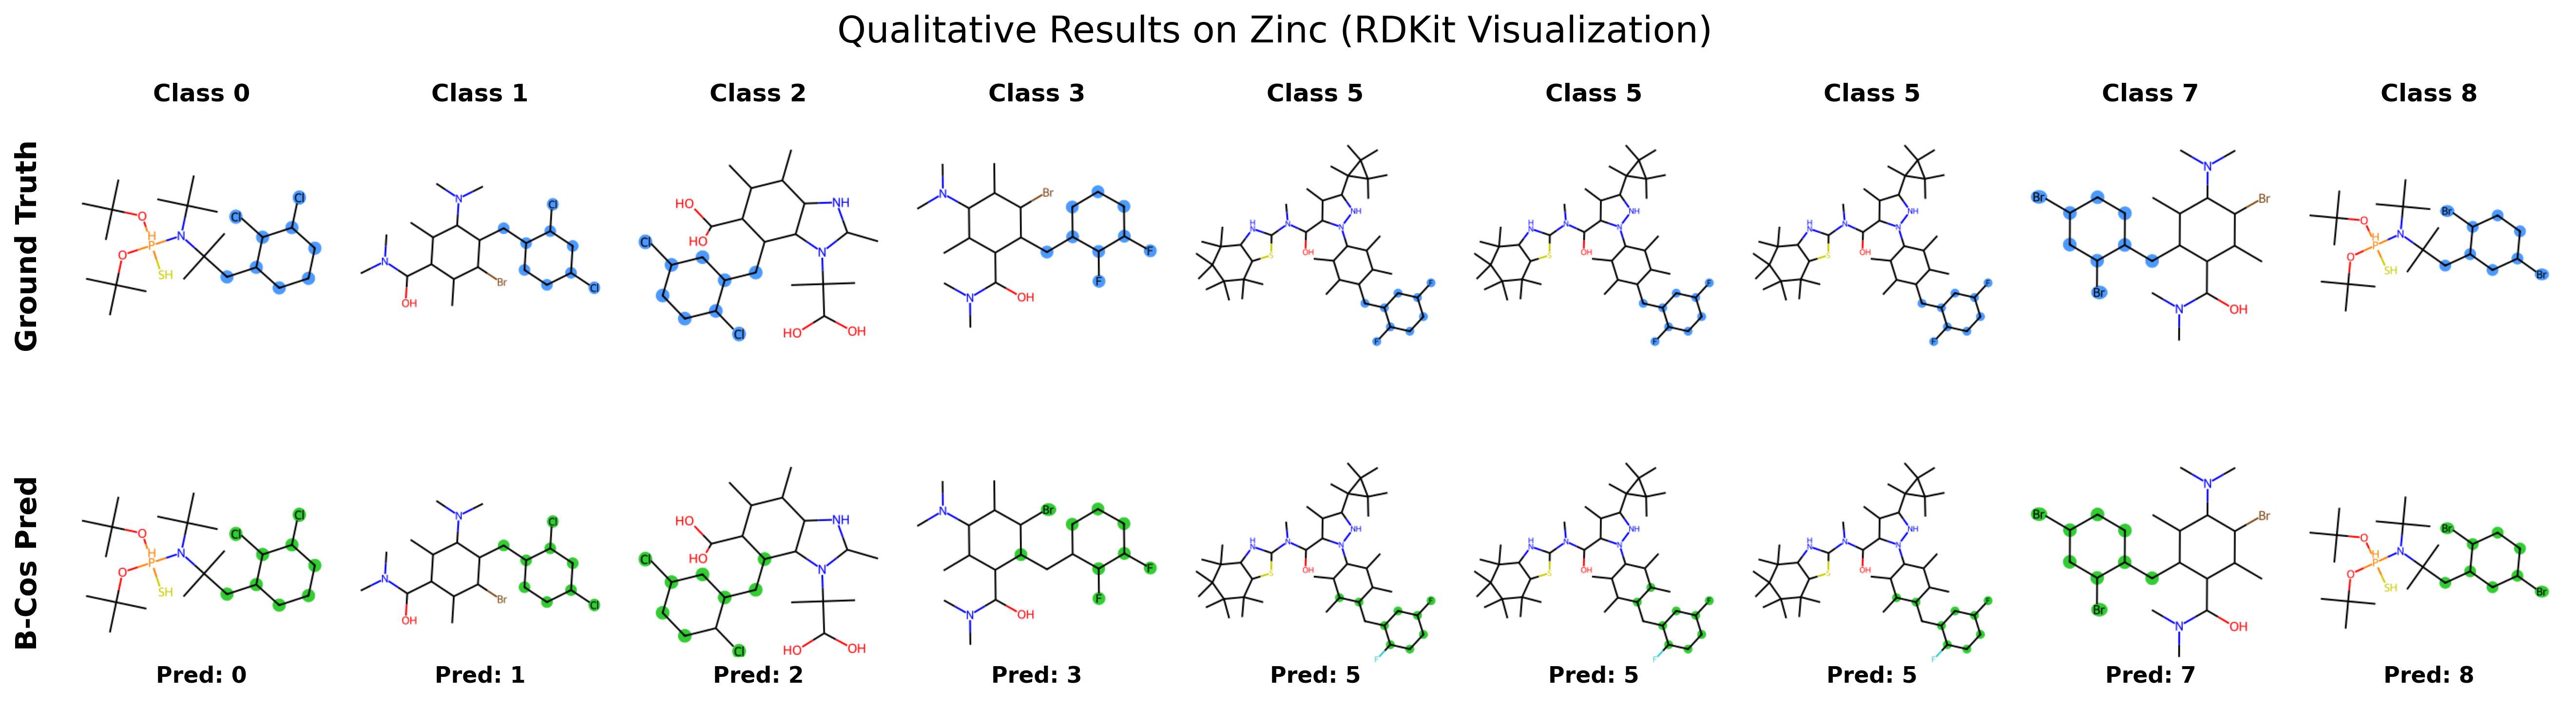

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem

# -------------------------------------------------------------------------
# 1. RDKit Conversion Utilities
# -------------------------------------------------------------------------
# ZINC atom map (Must match your dataset's feature encoding)
ATOM_MAP = {0: 6, 1: 7, 2: 8, 3: 16, 4: 9, 5: 17, 6: 35, 7: 53, 8: 15} # Atomic nums

def pyg_to_rdkit(data):
    """
    Converts a PyG graph to an RDKit molecule.
    Crucial step: We must infer bond types (Single, Double, Aromatic) 
    since standard GNN datasets often only store connectivity.
    """
    mol = Chem.RWMol()
    node_to_idx = {}
    
    # 1. Add Atoms
    for i in range(data.num_nodes):
        # Decode atom type
        if data.x.dim() > 1:
            atom_idx = data.x[i].argmax().item()
        else:
            atom_idx = int(data.x[i].item())
        
        atomic_num = ATOM_MAP.get(atom_idx, 6) # Default to Carbon if unknown
        atom = Chem.Atom(atomic_num)
        idx = mol.AddAtom(atom)
        node_to_idx[i] = idx

    # 2. Add Bonds (Initially all Single)
    edge_index = data.edge_index.cpu().numpy()
    # Use set to avoid adding double bonds for undirected edges (u,v) and (v,u)
    added_bonds = set()
    
    for k in range(edge_index.shape[1]):
        u, v = edge_index[0, k], edge_index[1, k]
        if u < v: # store only one direction
            mol.AddBond(int(node_to_idx[u]), int(node_to_idx[v]), Chem.BondType.SINGLE)
    
    # 3. Sanitize & Assign Bond Orders
    # This function attempts to figure out aromaticity and bond orders based on valency
    try:
        Chem.SanitizeMol(mol)
    except:
        pass # If sanitization fails, we still return the rough connectivity
        
    return mol

# -------------------------------------------------------------------------
# 2. Selection Logic (Same as before)
# -------------------------------------------------------------------------
def get_best_example_per_class(dataset, num_classes):
    candidates = {c: [] for c in range(num_classes)}
    indices = np.random.permutation(len(dataset))[:1000]
    
    for idx in indices:
        data = dataset[int(idx)]
        y = int(data.y.item()) if torch.is_tensor(data.y) else int(data.y)
        has_mask = hasattr(data, "explanation_mask") and data.explanation_mask is not None
        # RDKit draws look best with medium sized molecules
        if has_mask and 10 <= data.num_nodes <= 30:
             candidates[y].append(int(idx))
    
    selected = []
    for c in range(num_classes):
        if candidates[c]: selected.append(candidates[c][0])
        else: selected.append(0) # fallback
    return selected

# -------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(DEVICE)
final_model.eval()

selected_indices = get_best_example_per_class(test_ds, 9)
cols = len(selected_indices)

# Setup subplots
fig, axes = plt.subplots(2, cols, figsize=(22, 5.5), dpi=300)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

# Row Labels
rows = ["Ground Truth", "B-Cos Pred"]
for i, r in enumerate(rows):
    axes[i, 0].text(-0.1, 0.5, r, transform=axes[i, 0].transAxes, 
                    fontsize=14, fontweight='bold', rotation=90, va='center', ha='right')

print("Generating RDKit visualizations...")

for col, idx in enumerate(selected_indices):
    data = test_ds[idx].clone().to(DEVICE)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
    true_cls = int(data.y.item())
    
    # Convert to RDKit
    mol = pyg_to_rdkit(data)
    
    # ------------------------------------------------
    # 1. Row 1: Ground Truth (Blue Highlights)
    # ------------------------------------------------
    if hasattr(data, "explanation_mask") and data.explanation_mask is not None:
        gt_mask = data.explanation_mask.cpu().numpy().astype(bool)
        gt_atoms = [int(i) for i in np.where(gt_mask)[0]]
    else:
        gt_atoms = []

    img_gt = Draw.MolToImage(mol, size=(300, 300), 
                             highlightAtoms=gt_atoms,
                             highlightColor=(0.3, 0.6, 1.0)) # Light Blue
    
    axes[0, col].imshow(img_gt)
    axes[0, col].set_title(f"Class {true_cls}", fontsize=12, fontweight='bold')
    axes[0, col].axis('off')

    # ------------------------------------------------
    # 2. Row 2: Prediction (Green/Red Highlights)
    # ------------------------------------------------
    # Forward Pass
    with torch.no_grad():
        logits = final_model(data.x, data.edge_index, data.edge_attr, data.batch)
        pred_cls = logits.argmax(dim=-1).item()
    
    # Explain
    contrib = explain_edge_attr(final_model, data.x, data.edge_index, data.edge_attr, data.batch, target=pred_cls)
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu().numpy()
    
    # Top-K
    k = len(gt_atoms) if len(gt_atoms) > 0 else 5
    top_k_idx = np.argsort(scores)[-k:]
    pred_atoms = [int(i) for i in top_k_idx]
    
    # Color
    color = (0.2, 0.8, 0.2) if pred_cls == true_cls else (0.9, 0.2, 0.2) # Green or Red
    
    img_pred = Draw.MolToImage(mol, size=(300, 300), 
                               highlightAtoms=pred_atoms,
                               highlightColor=color)
    
    axes[1, col].imshow(img_pred)
    axes[1, col].text(0.5, 0.05, f"Pred: {pred_cls}", transform=axes[1, col].transAxes,
                      ha='center', fontsize=11, fontweight='bold', 
                      bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    axes[1, col].axis('off')

plt.suptitle("Qualitative Results on Zinc (RDKit Visualization)", fontsize=18, y=0.98)
plt.savefig("zinc_results_rdkit.pdf", bbox_inches='tight')
plt.show()

Generating HD RDKit visualizations...


[18:54:36] Explicit valence for atom # 2 N, 4, is greater than permitted
[18:54:36] Explicit valence for atom # 2 N, 4, is greater than permitted


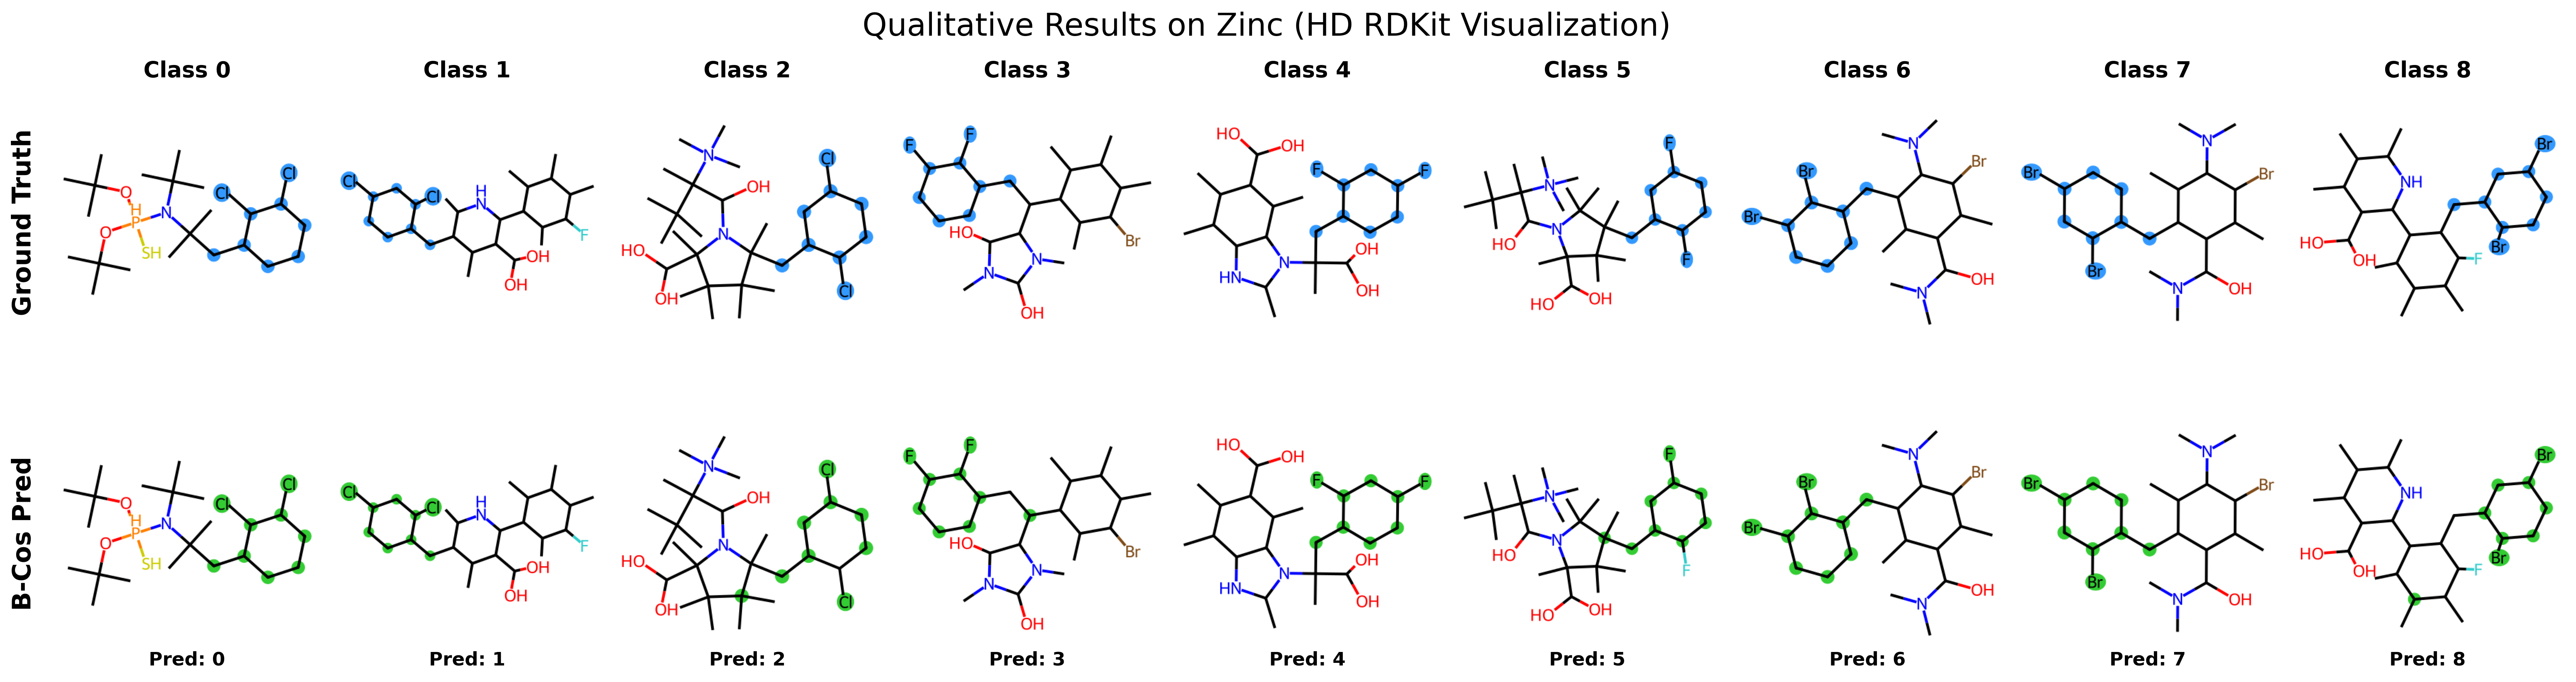

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D

# -------------------------------------------------------------------------
# 1. High-Definition RDKit Drawing Helper
# -------------------------------------------------------------------------
def draw_rdkit_hd(mol, highlight_atoms=None, highlight_color=(0.3, 0.6, 1.0)):
    """
    Draws a molecule with enlarged atoms and bonds for publication readability.
    """
    # 1. Setup Canvas (High Res)
    width, height = 400, 400
    d2d = rdMolDraw2D.MolDraw2DCairo(width, height)
    
    # 2. Customize Options (Make everything BIGGER)
    opts = d2d.drawOptions()
    opts.minFontSize = 24        # Minimum font size for atom labels
    opts.maxFontSize = 34        # Maximum font size
    opts.bondLineWidth = 4       # Thicker bonds
    opts.highlightBondWidthMultiplier = 1  # Keep highlights aligned with bonds
    opts.annotationFontScale = 1.0
    opts.padding = 0.05          # Less whitespace around the molecule
    
    # Ensure layout is computed
    if not mol.GetNumConformers():
        AllChem.Compute2DCoords(mol)

    # 3. Draw
    # Standardize highlighting format
    if highlight_atoms:
        # Create a dict for colors: {atom_idx: color_tuple}
        # Note: RDKit expects RGB tuples (0-1)
        hs = {idx: highlight_color for idx in highlight_atoms}
        d2d.DrawMolecule(mol, highlightAtoms=list(hs.keys()), highlightAtomColors=hs)
    else:
        d2d.DrawMolecule(mol)
        
    d2d.FinishDrawing()
    
    # 4. Convert to PIL Image for Matplotlib
    png_data = d2d.GetDrawingText()
    return Image.open(io.BytesIO(png_data))

# -------------------------------------------------------------------------
# 2. Conversion & Selection (Same as before)
# -------------------------------------------------------------------------
ATOM_MAP = {0: 6, 1: 7, 2: 8, 3: 16, 4: 9, 5: 17, 6: 35, 7: 53, 8: 15}

def pyg_to_rdkit(data):
    mol = Chem.RWMol()
    node_to_idx = {}
    
    # Add Atoms
    for i in range(data.num_nodes):
        if data.x.dim() > 1: atom_idx = data.x[i].argmax().item()
        else: atom_idx = int(data.x[i].item())
        mol.AddAtom(Chem.Atom(ATOM_MAP.get(atom_idx, 6)))
        node_to_idx[i] = i # RWMol indices are sequential

    # Add Bonds
    edge_index = data.edge_index.cpu().numpy()
    added = set()
    for k in range(edge_index.shape[1]):
        u, v = int(edge_index[0, k]), int(edge_index[1, k])
        if u < v:
            mol.AddBond(u, v, Chem.BondType.SINGLE)
            
    try: Chem.SanitizeMol(mol)
    except: pass
    return mol

def get_best_example_per_class(dataset, num_classes):
    candidates = {c: [] for c in range(num_classes)}
    indices = np.random.permutation(len(dataset))[:1000]
    for idx in indices:
        d = dataset[int(idx)]
        y = int(d.y.item()) if torch.is_tensor(d.y) else int(d.y)
        # Slightly relaxed constraints to ensure we find graphs
        if hasattr(d, "explanation_mask") and d.explanation_mask is not None:
             if 8 <= d.num_nodes <= 35: 
                 candidates[y].append(int(idx))
    
    selected = []
    for c in range(num_classes):
        selected.append(candidates[c][0] if candidates[c] else 0)
    return selected

# -------------------------------------------------------------------------
# 3. Main Plotting Loop (Updated)
# -------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(DEVICE)
final_model.eval()

selected_indices = get_best_example_per_class(test_ds, 9)
cols = len(selected_indices)

# Increase figure size significantly to accommodate the HD images
fig, axes = plt.subplots(2, cols, figsize=(24, 7), dpi=300)
plt.subplots_adjust(wspace=0.02, hspace=0.05, left=0.05, right=0.98)

# Row Labels
rows = ["Ground Truth", "B-Cos Pred"]
for i, r in enumerate(rows):
    axes[i, 0].text(-0.05, 0.5, r, transform=axes[i, 0].transAxes, 
                    fontsize=16, fontweight='bold', rotation=90, va='center', ha='right')

print("Generating HD RDKit visualizations...")

for col, idx in enumerate(selected_indices):
    data = test_ds[idx].clone().to(DEVICE)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
    true_cls = int(data.y.item())
    
    mol = pyg_to_rdkit(data)
    
    # --- Row 1: Ground Truth ---
    if hasattr(data, "explanation_mask") and data.explanation_mask is not None:
        gt_mask = data.explanation_mask.cpu().numpy().astype(bool)
        gt_atoms = [int(i) for i in np.where(gt_mask)[0]]
    else:
        gt_atoms = []

    # Use the new HD drawer
    img_gt = draw_rdkit_hd(mol, highlight_atoms=gt_atoms, highlight_color=(0.2, 0.6, 1.0)) # Bright Blue
    
    axes[0, col].imshow(img_gt)
    axes[0, col].set_title(f"Class {true_cls}", fontsize=14, fontweight='bold', pad=5)
    axes[0, col].axis('off')

    # --- Row 2: Prediction ---
    with torch.no_grad():
        logits = final_model(data.x, data.edge_index, data.edge_attr, data.batch)
        pred_cls = logits.argmax(dim=-1).item()
        
    contrib = explain_edge_attr(final_model, data.x, data.edge_index, data.edge_attr, data.batch, target=pred_cls)
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu().numpy()
    
    k = len(gt_atoms) if len(gt_atoms) > 0 else 5
    top_k_idx = np.argsort(scores)[-k:]
    pred_atoms = [int(i) for i in top_k_idx]
    
    color = (0.2, 0.8, 0.2) if pred_cls == true_cls else (0.9, 0.1, 0.1) # Green or Red
    
    img_pred = draw_rdkit_hd(mol, highlight_atoms=pred_atoms, highlight_color=color)
    
    axes[1, col].imshow(img_pred)
    axes[1, col].text(0.5, 0.02, f"Pred: {pred_cls}", transform=axes[1, col].transAxes,
                      ha='center', fontsize=12, fontweight='bold', 
                      bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.2'))
    axes[1, col].axis('off')

plt.suptitle("Qualitative Results on Zinc (HD RDKit Visualization)", fontsize=20, y=0.96)
plt.savefig("zinc_results_rdkit_hd.pdf", bbox_inches='tight')
plt.show()

Searching dataset for representative molecules...


[19:01:49] Explicit valence for atom # 8 N, 4, is greater than permitted


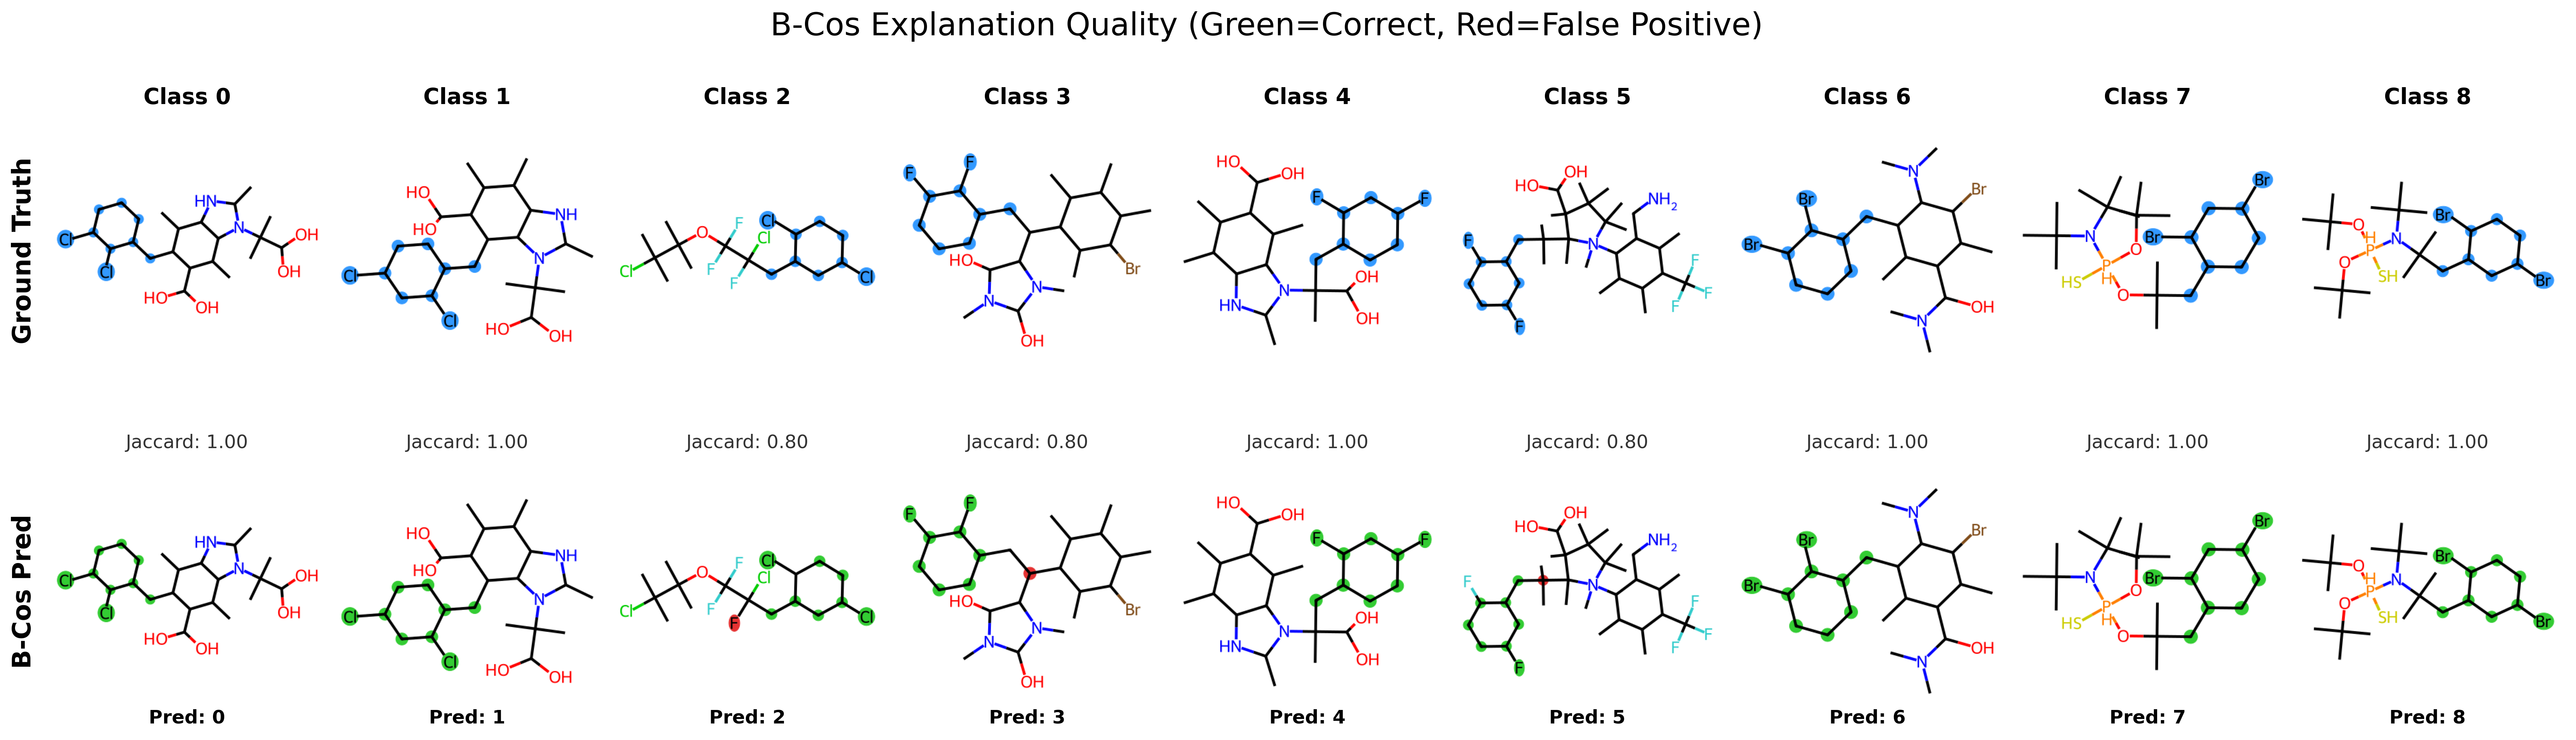

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D

# -------------------------------------------------------------------------
# 1. RDKit HD Drawer (Unchanged)
# -------------------------------------------------------------------------
def draw_rdkit_hd_mixed(mol, atom_colors=None):
    width, height = 400, 400
    d2d = rdMolDraw2D.MolDraw2DCairo(width, height)
    opts = d2d.drawOptions()
    opts.minFontSize = 24
    opts.maxFontSize = 34
    opts.bondLineWidth = 4
    opts.highlightBondWidthMultiplier = 1
    opts.padding = 0.05
    
    if not mol.GetNumConformers():
        AllChem.Compute2DCoords(mol)

    if atom_colors:
        d2d.DrawMolecule(mol, highlightAtoms=list(atom_colors.keys()), highlightAtomColors=atom_colors)
    else:
        d2d.DrawMolecule(mol)
        
    d2d.FinishDrawing()
    return Image.open(io.BytesIO(d2d.GetDrawingText()))

# -------------------------------------------------------------------------
# 2. Conversion Utilities (Unchanged)
# -------------------------------------------------------------------------
ATOM_MAP = {0: 6, 1: 7, 2: 8, 3: 16, 4: 9, 5: 17, 6: 35, 7: 53, 8: 15}

def pyg_to_rdkit(data):
    mol = Chem.RWMol()
    node_to_idx = {}
    for i in range(data.num_nodes):
        if data.x.dim() > 1: atom_idx = data.x[i].argmax().item()
        else: atom_idx = int(data.x[i].item())
        mol.AddAtom(Chem.Atom(ATOM_MAP.get(atom_idx, 6)))
        node_to_idx[i] = i 

    edge_index = data.edge_index.cpu().numpy()
    for k in range(edge_index.shape[1]):
        u, v = int(edge_index[0, k]), int(edge_index[1, k])
        if u < v:
            mol.AddBond(u, v, Chem.BondType.SINGLE)
            
    try: Chem.SanitizeMol(mol)
    except: pass
    return mol

# -------------------------------------------------------------------------
# 3. ROBUST Selection Logic (Fixed Bug Here)
# -------------------------------------------------------------------------
def get_best_example_per_class(dataset, num_classes):
    """
    Guarantees one example per class by searching the whole dataset 
    and using fallbacks if perfect constraints aren't met.
    """
    # 1. Buckets for candidates
    # strict: has mask + ideal size (10-30 atoms)
    # loose: has mask (any size)
    candidates_strict = {c: [] for c in range(num_classes)}
    candidates_loose = {c: [] for c in range(num_classes)}
    
    # Shuffle entire dataset indices to ensure randomness
    indices = np.random.permutation(len(dataset))
    
    print("Searching dataset for representative molecules...")
    
    for idx in indices:
        # Stop early if we have a strict candidate for every class
        if all(len(candidates_strict[c]) > 0 for c in range(num_classes)):
            break
            
        d = dataset[int(idx)]
        y = int(d.y.item()) if torch.is_tensor(d.y) else int(d.y)
        
        # Check if graph has a Ground Truth explanation mask
        has_mask = hasattr(d, "explanation_mask") and d.explanation_mask is not None
        if not has_mask: 
            continue
            
        # Add to loose candidates
        candidates_loose[y].append(int(idx))
        
        # Check strict size constraint (best for plotting)
        if 10 <= d.num_nodes <= 30:
            candidates_strict[y].append(int(idx))
    
    # 2. Select best available for each class
    selected = []
    for c in range(num_classes):
        if candidates_strict[c]:
            selected.append(candidates_strict[c][0])
        elif candidates_loose[c]:
            print(f"Warning: Class {c} using sub-optimal size graph.")
            selected.append(candidates_loose[c][0])
        else:
            raise ValueError(f"Could not find ANY valid example for Class {c} with an explanation mask!")
            
    return selected

# -------------------------------------------------------------------------
# 4. Main Plotting Loop
# -------------------------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
final_model.to(DEVICE)
final_model.eval()

# Should now correctly find 0 through 8
selected_indices = get_best_example_per_class(test_ds, 9)
cols = len(selected_indices)

fig, axes = plt.subplots(2, cols, figsize=(24, 7.5), dpi=300)
plt.subplots_adjust(wspace=0.02, hspace=0.1, left=0.05, right=0.98)

# Row Labels
rows = ["Ground Truth", "B-Cos Pred"]
for i, r in enumerate(rows):
    axes[i, 0].text(-0.05, 0.5, r, transform=axes[i, 0].transAxes, 
                    fontsize=16, fontweight='bold', rotation=90, va='center', ha='right')

for col, idx in enumerate(selected_indices):
    data = test_ds[idx].clone().to(DEVICE)
    data.batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)
    true_cls = int(data.y.item())
    
    mol = pyg_to_rdkit(data)
    
    # --- Row 1: Ground Truth (Blue) ---
    gt_indices = set()
    if hasattr(data, "explanation_mask") and data.explanation_mask is not None:
        mask = data.explanation_mask.cpu().numpy().astype(bool)
        gt_indices = set(int(i) for i in np.where(mask)[0])
    
    gt_colors = {i: (0.2, 0.6, 1.0) for i in gt_indices}
    
    img_gt = draw_rdkit_hd_mixed(mol, atom_colors=gt_colors)
    axes[0, col].imshow(img_gt)
    axes[0, col].set_title(f"Class {true_cls}", fontsize=14, fontweight='bold')
    axes[0, col].axis('off')

    # --- Row 2: Prediction (Green=TP, Red=FP) ---
    with torch.no_grad():
        logits = final_model(data.x, data.edge_index, data.edge_attr, data.batch)
        pred_cls = logits.argmax(dim=-1).item()
        
    contrib = explain_edge_attr(final_model, data.x, data.edge_index, data.edge_attr, data.batch, target=pred_cls)
    scores = contrib['x'].abs().sum(dim=-1).detach().cpu().numpy()
    
    # Top-K Logic
    k = len(gt_indices) if len(gt_indices) > 0 else 5
    top_k_idx = np.argsort(scores)[-k:]
    pred_indices = set(int(i) for i in top_k_idx)
    
    # Jaccard
    intersection = len(gt_indices.intersection(pred_indices))
    union = len(gt_indices.union(pred_indices))
    jaccard = intersection / union if union > 0 else 0.0
    
    # Colors
    pred_colors = {}
    for idx in pred_indices:
        if idx in gt_indices:
            pred_colors[idx] = (0.2, 0.8, 0.2) # Green
        else:
            pred_colors[idx] = (0.9, 0.2, 0.2) # Red
            
    img_pred = draw_rdkit_hd_mixed(mol, atom_colors=pred_colors)
    axes[1, col].imshow(img_pred)
    
    axes[1, col].set_title(f"Jaccard: {jaccard:.2f}", fontsize=12, color="#333333", pad=4)
    axes[1, col].text(0.5, 0.02, f"Pred: {pred_cls}", transform=axes[1, col].transAxes,
                      ha='center', fontsize=12, fontweight='bold', 
                      bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', boxstyle='round,pad=0.2'))
    axes[1, col].axis('off')

plt.suptitle("B-Cos Explanation Quality (Green=Correct, Red=False Positive)", fontsize=20, y=0.98)
plt.savefig("zinc_results_final_corrected.pdf", bbox_inches='tight')
plt.show()